In [1]:
pip install pandas


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

In [15]:
data=pd.read_csv("advanceemp.csv")
data

,Experience_Years,Projects_Completed,Job_Title,Certification_Completed,Salary
0,1,3,Software Engineer,3,450000
1,2,5,Web Developer,4,500000
2,3,8,Data Analyst,2,650000
3,4,10,Python Developer,2,800000
4,5,12,Data Engineer,3,950000
5,6,15,ML Engineer,5,1200000
6,7,18,DevOps Engineer,2,1400000
7,8,22,AI Engineer,4,1700000


In [16]:
pip install matplotlib


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


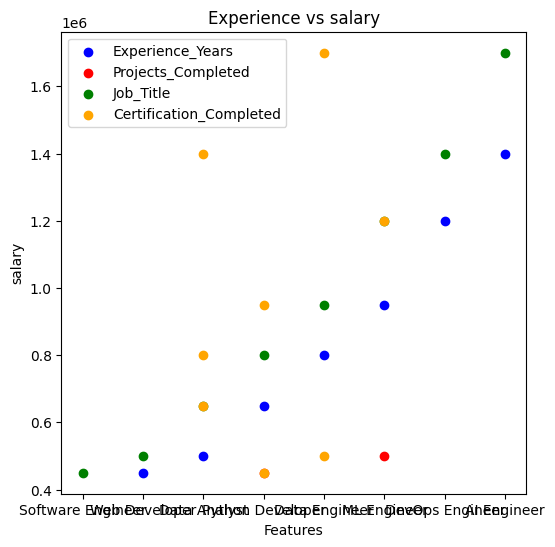

In [37]:
from matplotlib import pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(data['Experience_Years'], data['Salary'], color="blue", label="Experience_Years")
plt.scatter(data['Projects_Completed'], data['Salary'], color="red", label="Projects_Completed")
plt.scatter(data['Job_Title'], data['Salary'], color="green", label="Job_Title")
plt.scatter(data['Certification_Completed'], data['Salary'], color="orange", label="Certification_Completed")
plt.xlabel("Features")
plt.ylabel("salary")
plt.title("Experience vs salary")
plt.legend()
plt.show()

In [18]:
data_encoded=pd.get_dummies(data, columns=['Job_Title'])
data_encoded


,Experience_Years,Projects_Completed,Certification_Completed,Salary,Job_Title_AI Engineer,Job_Title_Data Analyst,Job_Title_Data Engineer,Job_Title_DevOps Engineer,Job_Title_ML Engineer,Job_Title_Python Developer,Job_Title_Software Engineer,Job_Title_Web Developer
0,1,3,3,450000,False,False,False,False,False,False,True,False
1,2,5,4,500000,False,False,False,False,False,False,False,True
2,3,8,2,650000,False,True,False,False,False,False,False,False
3,4,10,2,800000,False,False,False,False,False,True,False,False
4,5,12,3,950000,False,False,True,False,False,False,False,False
5,6,15,5,1200000,False,False,False,False,True,False,False,False
6,7,18,2,1400000,False,False,False,True,False,False,False,False
7,8,22,4,1700000,True,False,False,False,False,False,False,False


In [19]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [20]:
from sklearn.model_selection import train_test_split
y=data_encoded['Salary']
X=data_encoded.drop(columns=['Salary'])


In [21]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [35]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)
model.coef_
model.intercept_
predictions=model.predict(X_test)

In [26]:
predictions

array([ 450000., 1700000.,  650000.,  950000.,  800000., 1400000.])

In [27]:
print(X_train.shape)


(6, 11)


In [28]:
y_train

0     450000
7    1700000
2     650000
4     950000
3     800000
6    1400000
Name: Salary, dtype: int64

In [29]:
y_test


1     500000
5    1200000
Name: Salary, dtype: int64

In [32]:
from sklearn.metrics import r2_score

In [36]:
r2_score(y_test,predictions)

0.9712328275304716